## Step 1: Install Dependencies

In [47]:
%pip install -q \
    langchain-groq \
    langchain-community \
    "langgraph>=1.0.8,<1.1.0" \
    arize-otel \
    openinference-instrumentation-langchain \
    "opentelemetry-sdk>=1.35.0,<1.39.0" \
    "opentelemetry-api>=1.35.0,<1.39.0" \
    pymupdf \
    langgraph-checkpoint-sqlite \
    prettytable

## Step 2: Configure API Keys

In [48]:
from google.colab import userdata
import os

os.environ["GROQ_API_KEY"]    = userdata.get('GROQ_API_KEY')
os.environ["ARIZE_SPACE_ID"]  = userdata.get("ARIZE_SPACE_ID")
os.environ["ARIZE_API_KEY"]   = userdata.get("ARIZE_API_KEY")

print("✅ API Keys configured.")

✅ API Keys configured.


## Step 3: Arize Phoenix Tracing

In [49]:
from arize.otel import register
from openinference.instrumentation.langchain import LangChainInstrumentor

# Configure Arize tracing
tracer_provider = register(
    space_id=os.environ["ARIZE_SPACE_ID"],
    api_key=os.environ["ARIZE_API_KEY"],
    project_name="cease-desist-processing-system"
)

# Enable automatic LangChain instrumentation
LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

print("🔭 Arize observability configured successfully!")
print("📊 All LangChain operations will now be automatically traced")

🔭 OpenTelemetry Tracing Details 🔭
|  Arize Project: cease-desist-processing-system
|  Span Processor: BatchSpanProcessor
|  Collector Endpoint: otlp.arize.com
|  Transport: gRPC
|  Transport Headers: {'authorization': '****', 'api_key': '****', 'arize-space-id': '****', 'space_id': '****', 'arize-interface': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.

🔭 Arize observability configured successfully!
📊 All LangChain operations will now be automatically traced


## Step 4: Imports and LLM Initialization

In [50]:
# Cell 4: Core Imports and LLM Setup
from typing import Annotated, Optional, Literal
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import create_react_agent

from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel, Field

import fitz                      # PyMuPDF — renders scanned PDF pages to images
import base64
import sqlite3
import json
import datetime
import uuid
import os
from pathlib import Path

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_retries=2,
)

# ── Vision LLM: llama-4-scout for scanned / image-based PDFs (multimodal)
vision_llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    temperature=0,
    max_retries=2,
)

print(f"✅ Text LLM   : {llm.model_name}")
print(f"✅ Vision LLM : {vision_llm.model_name}")


✅ Text LLM   : llama-3.1-8b-instant
✅ Vision LLM : meta-llama/llama-4-scout-17b-16e-instruct


## Step 5: Define LangGraph State

In [51]:
# Cell 5: DocumentState Definition
class DocumentState(TypedDict):
    # ── Input ──────────────────────────────────────────────────────
    document_path:      Optional[str]    # Path to PDF on disk (if loading from file)
    document_text:      str              # Extracted / transcribed text content
    document_name:      str              # Display name (filename or label)
    extraction_method:  Optional[str]    # "text" | "vision" | "manual"

    # ── Classification output ──────────────────────────────────────
    classification:     Optional[str]    # "Cease" | "Irrelevant" | "Uncertain"
    confidence:         Optional[float]
    reasoning:          Optional[str]
    key_evidence:       Optional[list]
    legal_category:     Optional[str]    # Copyright, Trademark, Patent, Harassment …
    sender:             Optional[str]
    doc_date:           Optional[str]

    # ── Human-in-the-Loop ──────────────────────────────────────────
    hitl_assessment:    Optional[str]    # AI summary for human reviewer
    human_decision:     Optional[str]    # "Cease" | "Irrelevant" (set by human)

    # ── Audit trail (accumulated across all nodes, like add_messages) ─
    audit_log: Annotated[list, lambda existing, new: existing + new]

print("✅ DocumentState defined.")

✅ DocumentState defined.


## Step 6: PDF Loader Agent — Multimodal Support

`PyMuPDF (fitz)` handles both jobs:
- Digital PDFs → `page.get_text()` (fast, direct)
- Scanned / FAXED PDFs → `page.get_pixmap()` → base64 PNG → `llama-4-scout` vision model

In [52]:
# Cell 9: PDF Loader Helper Functions — PyMuPDF (fitz) for both text and image

def extract_text_with_fitz(pdf_path: str) -> str:
    """
    Extract text from a digital PDF using PyMuPDF (fitz).
    """
    try:
        doc  = fitz.open(pdf_path)
        pages = [page.get_text().strip() for page in doc]
        doc.close()
        return "\n\n".join(t for t in pages if t)
    except Exception as e:
        print(f"   fitz text extraction error: {e}")
        return ""

def extract_text_with_vision(pdf_path: str) -> str:
    """
    Convert PDF pages to images using PyMuPDF and send to Groq vision model.
    Used as fallback for scanned, FAXED, or image-based PDFs.
    """
    try:
        doc = fitz.open(pdf_path)
        all_pages_text = []

        for page in doc:
            mat     = fitz.Matrix(200/72, 200/72)   # 200 DPI
            pix     = page.get_pixmap(matrix=mat)
            img_b64 = base64.standard_b64encode(pix.tobytes("png")).decode("utf-8")

            response = vision_llm.invoke([{
                "role": "user",
                "content": [
                    {"type": "image_url",
                     "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
                    {"type": "text",
                     "text": (
                         "This is a scanned legal document. "
                         "Transcribe ALL visible text exactly as written. "
                         "Preserve structure and headings. Do not summarize."
                     )}
                ]
            }])
            all_pages_text.append(response.content)

        doc.close()
        return "\n\n".join(all_pages_text)

    except Exception as e:
        print(f"   Vision extraction error: {e}")
        return ""

def load_pdf(pdf_path: str) -> tuple[str, str]:
    """
    Smart loader using PyMuPDF for both text and image rendering.
    Step 1: Try fitz text extraction (digital PDFs)
    Step 2: If text insufficient → render pages as images → send to llama-4-scout vision
    """
    print(f"   📄 Loading: {Path(pdf_path).name}")
    text = extract_text_with_fitz(pdf_path)

    if len(" ".join(text.split())) >= 100:
        print(f"   ✅ Text extraction OK ({len(text)} chars)")
        return text, "text"

    print(f"   ⚠️  Text sparse ({len(text)} chars) — using vision model (multimodal)")
    text = extract_text_with_vision(pdf_path)

    if len(" ".join(text.split())) >= 50:
        print(f"   ✅ Vision extraction OK ({len(text)} chars)")
        return text, "vision"

    print("   ❌ Both methods failed")
    return f"[Could not extract: {Path(pdf_path).name}]", "failed"

print("   Text extraction : fitz.open().get_text()")
print("   Vision fallback : fitz page → PNG → llama-4-scout")

   Text extraction : fitz.open().get_text()
   Vision fallback : fitz page → PNG → llama-4-scout


In [53]:
# Cell 7: PDF Loader Agent Node

def pdf_loader_agent(state: DocumentState) -> dict:
    """
    PDF Loader Agent Node.
    Loads a PDF from disk and populates document_text in state.
    Uses multimodal fallback automatically for scanned/faxed documents.
    Skipped if document_text is already populated (e.g. from SAMPLE_DOCUMENTS).
    """
    print("\n--- 📂 Node: PDF Loader Agent ---")

    # Skip if text already provided
    if state.get("document_text") and len(state["document_text"]) > 50:
        method = state.get("extraction_method", "manual")
        print(f"   Text already provided ({len(state['document_text'])} chars) — skipping load.")
        return {"extraction_method": method}

    pdf_path = state.get("document_path")
    if not pdf_path:
        print("   No document_path — skipping.")
        return {}

    if not os.path.exists(pdf_path):
        return {
            "document_text": f"[File not found: {pdf_path}]",
            "extraction_method": "failed",
            "audit_log": [{
                "timestamp": datetime.datetime.now().isoformat(),
                "agent": "PDFLoaderAgent",
                "action": "LOAD_FAILED",
                "detail": f"File not found: {pdf_path}"
            }]
        }

    text, method = load_pdf(pdf_path)

    return {
        "document_text": text,
        "extraction_method": method,
        "audit_log": [{
            "timestamp": datetime.datetime.now().isoformat(),
            "agent": "PDFLoaderAgent",
            "action": "DOCUMENT_LOADED",
            "detail": f"Method={method}, Chars={len(text)}, File={Path(pdf_path).name}"
        }]
    }

print("✅ pdf_loader_agent node defined.")

✅ pdf_loader_agent node defined.


## Step 7: Persistent Storage
- `SqliteSaver` — LangGraph checkpointer , persists full state per thread
- `cease_records` table — lightweight results table for querying Cease records
- `irrelevant_archive.jsonl` — flat file for Irrelevant documents

In [54]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

conn   = sqlite3.connect("cease_desist_checkpoints.sqlite", check_same_thread=False)
memory = SqliteSaver(conn)
print("✅ SqliteSaver checkpointer ready: cease_desist_checkpoints.sqlite")

ARCHIVE_PATH = "irrelevant_archive.jsonl"

def init_results_db():
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS cease_records (
            id             TEXT PRIMARY KEY,
            timestamp      TEXT NOT NULL,
            document_name  TEXT,
            legal_category TEXT,
            sender         TEXT,
            doc_date       TEXT,
            confidence     REAL,
            reasoning      TEXT,
            source         TEXT
        )
    """)
    conn.commit()
    print("✅ cease_records results table ready.")

def store_cease_record(record: dict) -> str:
    import uuid, datetime
    record_id = str(uuid.uuid4())[:8].upper()
    cursor = conn.cursor()
    cursor.execute("""
        INSERT INTO cease_records
        (id, timestamp, document_name, legal_category, sender, doc_date, confidence, reasoning, source)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        record_id,
        datetime.datetime.now().isoformat(),
        record.get("document_name", "Unknown"),
        record.get("legal_category", "General"),
        record.get("sender", "Unknown"),
        record.get("doc_date", "Unknown"),
        record.get("confidence", 0.0),
        record.get("reasoning", ""),
        record.get("source", "system")
    ))
    conn.commit()
    return record_id

def store_archive_entry(entry: dict) -> str:
    import uuid, datetime, json
    entry_id = str(uuid.uuid4())[:8].upper()
    entry.update({"id": entry_id, "timestamp": datetime.datetime.now().isoformat()})
    with open(ARCHIVE_PATH, "a") as f:
        f.write(json.dumps(entry) + "\n")
    return entry_id

def query_cease_records():
    cursor = conn.cursor()
    cursor.execute("""
        SELECT id, timestamp, document_name, legal_category, sender, confidence, source
        FROM cease_records ORDER BY timestamp DESC
    """)
    return cursor.fetchall()

def query_archive():
    import json
    entries = []
    try:
        with open(ARCHIVE_PATH) as f:
            for line in f:
                line = line.strip()
                if line:
                    entries.append(json.loads(line))
    except FileNotFoundError:
        pass
    return entries

init_results_db()
print(f"✅ Archive flat file: {ARCHIVE_PATH}")

✅ SqliteSaver checkpointer ready: cease_desist_checkpoints.sqlite
✅ cease_records results table ready.
✅ Archive flat file: irrelevant_archive.jsonl


In [55]:
# Cell 9: Pydantic Schema for Classification Agent

class ClassificationOutput(BaseModel):
    """Structured output from the Classification Agent."""
    classification: Literal["Cease", "Irrelevant", "Uncertain"] = Field(
        description="Cease=explicit stop-all-comms demand; Irrelevant=not a cease request; Uncertain=ambiguous"
    )
    confidence: float = Field(ge=0.0, le=1.0, description="Confidence score 0.0–1.0")
    reasoning: str = Field(description="One-sentence explanation for the classification")
    key_evidence: list[str] = Field(description="Key phrases from the document supporting classification")
    legal_category: str = Field(
        description=(
            "Legal category: Copyright, Trademark, Patent, Trade Secret, Harassment, "
            "Software License, Non-Compete, NDA/Contract, Defamation, Debt/LOA, General, or Other"
        )
    )
    sender: str = Field(description="Exact law firm or sender name as it appears in the document letterhead or signature. Extract verbatim — e.g. 'Pinnacle Law Group', 'Five Lakes Law Group PLLC', 'Harridan & Sutherland'. Never use a placeholder.")
    doc_date: str = Field(description="Document date exactly as written in the document, e.g. 'March 10, 2026' or '6/29/2025'. Use Unknown only if no date exists.")

classification_llm = llm.with_structured_output(ClassificationOutput)

print("✅ ClassificationOutput Pydantic schema bound to LLM via with_structured_output().")

✅ ClassificationOutput Pydantic schema bound to LLM via with_structured_output().


## Step 9: Agent Nodes

In [56]:
# Cell 10: Classification Agent Node

CLASSIFICATION_SYSTEM_PROMPT = """You are a Classification Agent for a Cease & Desist Document Processing System.

Classify each document into exactly one of three categories: Cease, Irrelevant, or Uncertain.

──────────────────────────────────────────────────────
RULE 1 — "Cease" requires ALL of the following:
  • An EXPLICIT phrase such as "cease and desist all communications" OR
    "formally instruct all parties to cease and desist" OR
    "do not contact me by any mode of communication"
  • A clear instruction that ALL contact must stop immediately
  • No hedging — the demand is unconditional

Examples that ARE Cease:
  - "Cease and desist all communications regarding this account"
  - "I formally instruct all parties to cease and desist from contacting me"
  - "Do not contact me by any mode of communication including phone, email, letters"

──────────────────────────────────────────────────────
RULE 2 — "Irrelevant" if the document does NOT demand communications stop. Examples:
  - Informational POA notice (just notifying, no cease demand)
  - Settlement proposal or billing dispute
  - Document production / audit request
  - Guardianship or estate administrator notification

──────────────────────────────────────────────────────
RULE 3 — "Uncertain" if the document uses HEDGING language that falls short of an
explicit cease demand. Key signals:
  - Document itself says it is NOT a cease demand ("does not explicitly demand")
  - "temporary suspension", "pending confirmation", "until review is complete"
  - "refrain from initiating further contact" WITHOUT saying cease all communications
  - Requests verification of authority rather than demanding all contact stops
  - Deliberately circumspect or ambiguous wording

CRITICAL RULES:
  • If the document says "does not explicitly demand cessation" → ALWAYS Uncertain
  • If the document asks you to "verify authority" or "confirm legal basis" → Uncertain
  • NEVER infer or assume cease language that is not literally present in the text
  • Legal category must come from the document content — do NOT invent categories
  • If no legal category is mentioned, use "General"
"""

def classification_agent(state: DocumentState) -> dict:
    """
    Classification Agent Node.
    Uses structured output (Pydantic BaseModel) with ChatGroq — L7 standard.
    """
    print("\n--- 🤖 Node: Classification Agent ---")

    doc_text = state.get("document_text", "")
    if not doc_text or len(doc_text) < 20:
        return {
            "classification": "Uncertain",
            "confidence": 0.0,
            "reasoning": "No document text available.",
            "key_evidence": [],
            "legal_category": "Unknown",
            "sender": "Unknown",
            "doc_date": "Unknown",
            "messages": [AIMessage(content="Classification: no text, flagged Uncertain.")],
            "audit_log": [{
                "timestamp": datetime.datetime.now().isoformat(),
                "agent": "ClassificationAgent",
                "action": "CLASSIFICATION_FAILED",
                "detail": "No text available"
            }]
        }

    prompt = ChatPromptTemplate.from_messages([
        ("system", CLASSIFICATION_SYSTEM_PROMPT),
        ("human", "Classify this document. Base your answer ONLY on what is literally written.\n\n{document_text}")
    ])

    chain = prompt | classification_llm
    result: ClassificationOutput = chain.invoke({"document_text": doc_text[:8000]})

    print(f"   Classification  : {result.classification}")
    print(f"   Legal Category  : {result.legal_category}")
    print(f"   Confidence      : {result.confidence:.0%}")
    print(f"   Sender          : {result.sender}")
    print(f"   Reasoning       : {result.reasoning}")

    return {
        "classification": result.classification,
        "confidence": result.confidence,
        "reasoning": result.reasoning,
        "key_evidence": result.key_evidence,
        "legal_category": result.legal_category,
        "sender": result.sender,
        "doc_date": result.doc_date,
        "messages": [AIMessage(content=f"Classification: {result.classification} ({result.confidence:.0%}) — {result.legal_category}")],
        "audit_log": [{
            "timestamp": datetime.datetime.now().isoformat(),
            "agent": "ClassificationAgent",
            "action": "CLASSIFIED",
            "detail": f"{result.classification} | {result.legal_category} | conf={result.confidence:.0%}"
        }]
    }

print("✅ classification_agent defined.")

✅ classification_agent defined.


### Node 2: Database Agent — calls @tool store_cease_record

In [57]:
# Cell 11: Database Agent Node

def database_agent(state: DocumentState) -> dict:
    """
    Stores Cease records in SQLite.
    Runs for: classification=='Cease' OR human_decision=='Cease'.
    Skips if human decided Irrelevant (parallel execution after HITL).
    """
    print("\n--- 🗄️  Node: Database Agent ---")

    # Skip if human overrode to Irrelevant
    if state.get("human_decision") == "Irrelevant":
        print("   Skipping — human decision was Irrelevant.")
        return {}

    source = "human_override" if state.get("human_decision") == "Cease" else "system"

    record_id = store_cease_record({
        "document_name":    state["document_name"],
        "legal_category":   state.get("legal_category", "General"),
        "sender":           state.get("sender", "Unknown"),
        "doc_date":         state.get("doc_date", "Unknown"),
        "confidence":       state.get("confidence", 0.0),
        "reasoning":        state.get("reasoning", ""),
        "extraction_method": state.get("extraction_method", "unknown"),
        "source":           source,
    })

    print(f"   ✅ Stored    : CEASE-{record_id}")
    print(f"   Document    : {state['document_name']}")
    print(f"   Category    : {state.get('legal_category')}")
    print(f"   Source      : {source}")

    return {"audit_log": [{
        "timestamp": datetime.datetime.now().isoformat(),
        "agent":  "DatabaseAgent",
        "action": "STORED_CEASE_RECORD",
        "detail": f"ID=CEASE-{record_id} | Category={state.get('legal_category')} | Source={source}"
    }]}

print("✅ database_agent defined.")

✅ database_agent node defined.


### Node 3: Archiving Agent — calls @tool store_archive_entry

In [58]:
# Cell 12: Archiving Agent Node

def archiving_agent(state: DocumentState) -> dict:
    """
    Archives Irrelevant records to flat JSONL file.
    Runs for: classification=='Irrelevant' OR human_decision=='Irrelevant'.
    Skips if human decided Cease (parallel execution after HITL).
    """
    print("\n--- 📁 Node: Archiving Agent ---")

    # Skip if human overrode to Cease
    if state.get("human_decision") == "Cease":
        print("   Skipping — human decision was Cease.")
        return {}

    source = "human_override" if state.get("human_decision") == "Irrelevant" else "system"

    entry_id = store_archive_entry({
        "document_name":    state["document_name"],
        "sender":           state.get("sender", "Unknown"),
        "doc_date":         state.get("doc_date", "Unknown"),
        "reasoning":        state.get("reasoning", ""),
        "extraction_method": state.get("extraction_method", "unknown"),
        "source":           source,
    })

    print(f"   ✅ Archived  : ARCH-{entry_id}")
    print(f"   Document    : {state['document_name']}")
    print(f"   Source      : {source}")

    return {"audit_log": [{
        "timestamp": datetime.datetime.now().isoformat(),
        "agent":  "ArchivingAgent",
        "action": "ARCHIVED_IRRELEVANT",
        "detail": f"ID=ARCH-{entry_id} | Source={source}"
    }]}

print("✅ archiving_agent defined.")

✅ archiving_agent node defined.


### Node 4: HITL Agent — graph interrupts before this node

In [59]:
# Cell 13: HITL Agent Node
# Graph pauses AFTER this node (interrupt_after) so:
# 1. hitl_agent runs → generates assessment → writes FLAGGED_FOR_HUMAN_REVIEW audit entry
# 2. Graph pauses
# 3. Human decides → writes HITL_DECISION audit entry
# Result: correct audit order guaranteed

HITL_SYSTEM_PROMPT = """You are a Human-in-the-Loop Assessment Agent for a legal document processing system.
A document was classified as 'Uncertain' and requires human review.

Write exactly 3 sentences in plain prose (no bullet points, no headers):
1. What specifically makes this document ambiguous and hard to classify automatically.
2. The strongest argument FOR classifying it as 'Cease' (stop all communications demand).
3. The strongest argument FOR classifying it as 'Irrelevant' (not a cease request).
"""

def hitl_agent(state: DocumentState) -> dict:
    """
    HITL Agent Node.
    Runs fully, generates assessment, writes its audit entry, then graph pauses.
    Human decision is written after the pause — correct order preserved.
    """
    print("\n--- 👤 Node: HITL Agent ---")
    print("   Generating assessment for human reviewer...")

    prompt = ChatPromptTemplate.from_messages([
        ("system", HITL_SYSTEM_PROMPT),
        ("human", "Document text:\n{document_text}\n\nAI reasoning: {reasoning}")
    ])
    chain      = prompt | llm | StrOutputParser()
    assessment = chain.invoke({
        "document_text": state.get("document_text", "")[:4000],
        "reasoning":     state.get("reasoning", "No reasoning available.")
    })

    print("   📋 Assessment generated. Graph will pause after this node.")

    return {
        "hitl_assessment": assessment,
        "messages": [AIMessage(content="HITL Agent: assessment ready for human review.")],
        "audit_log": [{
            "timestamp": datetime.datetime.now().isoformat(),
            "agent":  "HITLAgent",
            "action": "FLAGGED_FOR_HUMAN_REVIEW",
            "detail": "Assessment generated — awaiting human decision"
        }]
    }

print("✅ hitl_agent defined (interrupt_after pattern).")

✅ hitl_agent defined.


### Node 5: Audit Agent — always runs last

In [60]:
# Cell 14: Audit Agent Node

def audit_agent(state: DocumentState) -> dict:
    """Audit Agent — always runs last, prints complete audit trail."""
    print("\n--- 📋 Node: Audit Agent ---")
    final = state.get("human_decision") or state.get("classification", "Unknown")

    print("\n" + "="*72)
    print("  AUDIT TRAIL")
    print("="*72)
    print(f"  Document         : {state['document_name']}")
    print(f"  Extraction       : {state.get('extraction_method', 'N/A')}")
    print(f"  AI Classification: {state.get('classification')} ({state.get('confidence', 0):.0%})")
    print(f"  Legal Category   : {state.get('legal_category')}")
    print(f"  Final Decision   : {final}")
    print("-"*72)
    for i, entry in enumerate(state.get("audit_log", []), 1):
        ts     = entry.get("timestamp","")[:23].replace("T"," ")
        agent  = entry.get("agent","")
        action = entry.get("action","")
        detail = entry.get("detail","")
        print(f"  [{i:02d}] {ts} | {agent:<22} | {action:<30} | {detail}")
    print("="*72)
    return {}

print("✅ audit_agent defined.")

✅ audit_agent defined.


## Step 10: Manager Router

In [61]:
# Cell 15: Manager Router
# post_hitl_router is no longer needed — parallel edges handle routing after HITL

def manager_router(state: DocumentState) -> str:
    """
    Routes based on classification result.
    Cease → database_agent
    Irrelevant → archiving_agent
    Uncertain → hitl_agent (graph pauses before this node)
    """
    classification = state.get("classification")
    print(f"\n--- 🔀 Manager Router: {classification} ---")
    if classification == "Cease":
        return "database_agent"
    elif classification == "Irrelevant":
        return "archiving_agent"
    else:
        return "hitl_agent"

print("✅ manager_router defined.")

✅ manager_router and post_hitl_router defined.


## Step 11: Build LangGraph State Machine

In [62]:
# Cell 16: Build and Compile the LangGraph
# interrupt_after=["hitl_agent"] — graph pauses AFTER hitl_agent completes
# This ensures HITLAgent audit entry is written BEFORE human decision

builder = StateGraph(DocumentState)

builder.add_node("pdf_loader_agent",     pdf_loader_agent)
builder.add_node("classification_agent", classification_agent)
builder.add_node("database_agent",       database_agent)
builder.add_node("archiving_agent",      archiving_agent)
builder.add_node("hitl_agent",           hitl_agent)
builder.add_node("audit_agent",          audit_agent)

builder.add_edge(START, "pdf_loader_agent")
builder.add_edge("pdf_loader_agent", "classification_agent")

# Cease → DB, Irrelevant → Archive, Uncertain → HITL
builder.add_conditional_edges(
    "classification_agent",
    manager_router,
    {
        "database_agent":  "database_agent",
        "archiving_agent": "archiving_agent",
        "hitl_agent":      "hitl_agent",
    }
)

# HITL → parallel fan-out to both storage agents
# Each agent has skip logic — only the correct one stores data
builder.add_edge("hitl_agent", "database_agent")
builder.add_edge("hitl_agent", "archiving_agent")

builder.add_edge("database_agent",  "audit_agent")
builder.add_edge("archiving_agent", "audit_agent")
builder.add_edge("audit_agent",     END)

# interrupt_after: hitl_agent runs fully first, THEN graph pauses
graph = builder.compile(
    checkpointer=memory,
    interrupt_after=["hitl_agent"]
)

print("✅ LangGraph compiled.")
print(f"   Nodes       : {list(builder.nodes.keys())}")
print(f"   Interrupt   : after ['hitl_agent'] — audit order preserved")
print(f"   Parallel    : database_agent + archiving_agent after HITL")
print(f"   Checkpointer: SqliteSaver")

✅ LangGraph compiled.
   Nodes       : ['pdf_loader_agent', 'classification_agent', 'database_agent', 'archiving_agent', 'hitl_agent', 'audit_agent']
   Interrupt   : after ['hitl_agent']  ← Lab 3.2 pattern (corrected)
   Checkpointer: MemorySaver             ← Lab 3.1 pattern


## Step 12: Visualize the Graph

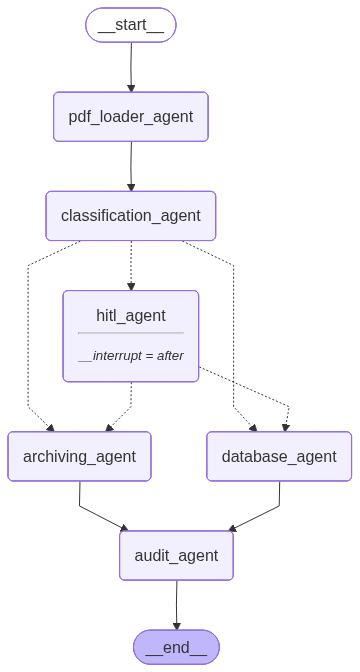

In [63]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

## Step 13: Pipeline Helper Functions

In [64]:
# Cell 19: run_pipeline() — accepts a PDF file path or raw text

def run_pipeline(source, document_name: str = None, thread_id: str = None) -> dict:
    """
    Run the full pipeline for a document.
    Accepts a PDF file path or raw text string.
    Returns thread_config — pass to HITL decision cell if graph pauses.
    """
    import uuid
    thread_id     = thread_id or f"thread-{uuid.uuid4().hex[:8]}"
    thread_config = {"configurable": {"thread_id": thread_id}}

    if isinstance(source, str) and source.strip().lower().endswith(".pdf") and os.path.exists(source):
        initial_state = {
            "document_path": source,
            "document_text": "",
            "document_name": document_name or Path(source).name,
            "messages":      [],
            "audit_log":     [],
        }
    else:
        initial_state = {
            "document_path": None,
            "document_text": source,
            "document_name": document_name or "Custom Document",
            "messages":      [],
            "audit_log":     [],
        }

    print("\n" + "="*72)
    print(f"  PROCESSING : {initial_state['document_name']}")
    print(f"  Thread ID  : {thread_id}")
    print("="*72)

    for event in graph.stream(initial_state, config=thread_config, stream_mode="updates"):
        pass

    state = graph.get_state(thread_config)
    if state.next:
        print(f"\n⏸️  GRAPH PAUSED — awaiting human review")
        print(f"   → Run the next cell to review and decide")
    else:
        print("\n✅ Pipeline complete.")

    return thread_config

print("✅ run_pipeline() defined.")

✅ run_pipeline() defined.


In [65]:
# interrupt_after means hitl_agent already ran — state has assessment ready

def inspect_hitl(thread_config: dict):
    """Show HITL state — classification, evidence, and AI assessment."""
    state = graph.get_state(thread_config)
    vals  = state.values

    print("\n" + "="*72)
    print("  ⚠️  HUMAN REVIEW REQUIRED")
    print("="*72)
    print(f"  Document       : {vals.get('document_name')}")
    print(f"  AI Class       : {vals.get('classification')} ({vals.get('confidence', 0):.0%} confidence)")
    print(f"  Legal Category : {vals.get('legal_category')}")
    print(f"  Extraction     : {vals.get('extraction_method')}")
    print(f"  AI Reasoning   : {vals.get('reasoning')}")
    print("\n  Key Evidence:")
    for e in vals.get("key_evidence", []):
        print(f'    • "{e}"')
    print("\n  📋 AI Assessment:")
    print(f"  {vals.get('hitl_assessment', 'Not yet generated')}")
    print("="*72)
    print("  → Type your decision in the next cell")

def resume_hitl(thread_config: dict, decision: Literal["Cease", "Irrelevant"]):
    """
    Resume graph after human review 
    Human entry written BEFORE stream so insertion order is:
      HITLAgent (already written before pause) → Human → StorageAgent
    """
    if decision not in ("Cease", "Irrelevant"):
        raise ValueError("decision must be 'Cease' or 'Irrelevant'")

    print(f"\n--- 👤 Human Decision: {decision} ---")

    # Write human entry BEFORE resuming — inserts before storage agent entries
    graph.update_state(
        thread_config,
        {
            "human_decision": decision,
            "audit_log": [{
                "timestamp": datetime.datetime.now().isoformat(),
                "agent":  "Human",
                "action": "HITL_DECISION",
                "detail": f"Human classified as: {decision}"
            }]
        }
    )

    # Resume — storage agents run and append their entries after Human
    print("   Resuming graph...")
    for event in graph.stream(None, config=thread_config, stream_mode="updates"):
        pass

    print("\n✅ HITL pipeline complete.")

print("✅ inspect_hitl() and resume_hitl() defined.")

✅ inspect_hitl() and resume_hitl() defined (Lab 3.2 pattern).


## Step 14: Process Your Document

In [71]:
file_path = input("Enter full path to your PDF (e.g. /content/LOA7.pdf): ").strip()
thread_config = run_pipeline(file_path)

Enter full path to your PDF (e.g. /content/LOA7.pdf): /content/notice_2.pdf

  PROCESSING : notice_2.pdf
  Thread ID  : thread-b327cc1e

--- 📂 Node: PDF Loader Agent ---
   📄 Loading: notice_2.pdf
   ⚠️  Text sparse (0 chars) — using vision model (multimodal)
   ✅ Vision extraction OK (8527 chars)

--- 🤖 Node: Classification Agent ---
   Classification  : Uncertain
   Legal Category  : Regulatory
   Confidence      : 80%
   Sender          : Lowell & Partners — Regulatory Practice
   Reasoning       : The document requests a temporary suspension of certain outbound correspondences and verification of authority, which falls short of an explicit cease demand.

--- 🔀 Manager Agent: Routing → Uncertain ---

--- 👤 Node: HITL Agent ---
   Generating assessment for human reviewer...
   📋 Assessment generated. ⏸️  Awaiting human decision.

--- 🔀 Post-HITL Router: Human decided → None ---

⏸️  GRAPH PAUSED — awaiting human review
   → Run the next cell to review and decide


/usr/local/lib/python3.12/dist-packages/openinference/instrumentation/_spans.py:42: LangChainDeprecationWarning: Calling .text() as a method is deprecated. Use .text as a property instead (e.g., message.text).
  masked_value = self._self_config.mask(key, value)


In [72]:
# If graph paused — run this cell to provide your decision
state = graph.get_state(thread_config)
if state.next:
    inspect_hitl(thread_config)

    user_input = input("\nYour decision: ").strip()

    # LLM interprets intent — handles any phrasing
    intent_prompt = ChatPromptTemplate.from_messages([
        ("system", "You decide if the user wants to classify a document as Cease or Irrelevant. "
                   "Reply with exactly one word: Cease or Irrelevant. Nothing else."),
        ("human", "{user_input}")
    ])
    decision = (intent_prompt | llm | StrOutputParser()).invoke({"user_input": user_input}).strip().title()
    if decision not in ("Cease", "Irrelevant"):
        decision = "Irrelevant"

    print(f"   Interpreted as: {decision}")
    resume_hitl(thread_config, decision)
else:
    print("No HITL required — pipeline already complete.")


  ⚠️  HUMAN REVIEW REQUIRED
  Document       : notice_2.pdf
  AI Class       : Uncertain (80% confidence)
  Legal Category : Regulatory
  Extraction     : vision
  AI Reasoning   : The document requests a temporary suspension of certain outbound correspondences and verification of authority, which falls short of an explicit cease demand.

  Key Evidence:
    • "temporary suspension"
    • "verification of authority"

  📋 AI Assessment for Human Reviewer:
  This document is ambiguous and hard to classify automatically because it requests a temporary suspension of certain outbound correspondences and verification of authority, which is a nuanced request that doesn't clearly categorize as a cease demand or an irrelevant communication. The language used is deliberately framed to require verification rather than to categorically bar all forms of contact, making it difficult for the AI to determine the intent behind the request. 

The strongest argument FOR classifying it as 'Cease' is that

## Step 15: Query Stored Records
Shows all records across all three storage mechanisms — Cease DB, Irrelevant Archive, and Audit Trail.

In [73]:
from prettytable import PrettyTable

rows = query_cease_records()
t = PrettyTable(["ID", "Timestamp", "Document", "Category", "Confidence", "Source"])
t.align = "l"
for row in rows:
    rid, ts, doc, cat, sender, conf, src = row
    t.add_row([
        rid,
        ts[:19].replace("T", " "),
        doc[:30] if doc else "",
        cat[:18] if cat else "",
        f"{conf:.0%}" if isinstance(conf, float) else str(conf),
        src
    ])
print("\n📊 CEASE & DESIST DATABASE")
print(t)
print(f"Total: {len(rows)}")


📊 CEASE & DESIST DATABASE
+----+-----------+----------+----------+------------+--------+
| ID | Timestamp | Document | Category | Confidence | Source |
+----+-----------+----------+----------+------------+--------+
+----+-----------+----------+----------+------------+--------+
Total: 0


In [74]:
from prettytable import PrettyTable

entries = query_archive()
t = PrettyTable(["ID", "Timestamp", "Document", "Sender", "Source"])
t.align = "l"
for e in entries:
    t.add_row([
        f"ARCH-{e.get('id','N/A')}",
        e.get('timestamp','')[:19].replace('T',' '),
        (e.get('document_name','')),
        (e.get('sender','')),
        e.get('source','')
    ])
print("\n📁 IRRELEVANT DOCUMENTS ARCHIVE")
print(t)
print(f"Total: {len(entries)}")


📁 IRRELEVANT DOCUMENTS ARCHIVE
+---------------+---------------------+--------------+------------------------------------------+----------------+
| ID            | Timestamp           | Document     | Sender                                   | Source         |
+---------------+---------------------+--------------+------------------------------------------+----------------+
| ARCH-024BEAA7 | 2026-03-22 02:27:09 | notice_1.pdf | Harridan & Sutherland, Counselors at Law | human_override |
| ARCH-25774BAB | 2026-03-22 02:34:34 | notice_1.pdf | Harridan & Sutherland, Counselors at Law | system         |
| ARCH-6E277792 | 2026-03-22 02:35:36 | notice_2.pdf | Lowell & Partners — Regulatory Practice  | human_override |
+---------------+---------------------+--------------+------------------------------------------+----------------+
Total: 3


In [76]:
from prettytable import PrettyTable

state = graph.get_state(thread_config)
logs  = state.values.get("audit_log", [])

t = PrettyTable(["#", "Timestamp", "Agent", "Action", "Detail"])
t.align = "l"
for idx, entry in enumerate(logs, 1):
    t.add_row([
        idx,
        entry.get("timestamp","")[:23].replace("T", " "),
        entry.get("agent",""),
        entry.get("action",""),
        entry.get("detail","")[:50]
    ])
print("\n📋 AUDIT TRAIL")
print(t)
print(f"Total entries: {len(logs)}")


📋 AUDIT TRAIL
+---+-------------------------+---------------------+--------------------------+------------------------------------------------+
| # | Timestamp               | Agent               | Action                   | Detail                                         |
+---+-------------------------+---------------------+--------------------------+------------------------------------------------+
| 1 | 2026-03-22 02:35:13.286 | PDFLoaderAgent      | DOCUMENT_LOADED          | Method=vision, Chars=8527, File=notice_2.pdf   |
| 2 | 2026-03-22 02:35:14.042 | ClassificationAgent | CLASSIFIED               | Uncertain | Regulatory | conf=80%              |
| 3 | 2026-03-22 02:35:21.963 | HITLAgent           | FLAGGED_FOR_HUMAN_REVIEW | Assessment generated — awaiting human decision |
| 4 | 2026-03-22 02:35:36.916 | Human               | HITL_DECISION            | Human classified as: Irrelevant                |
| 5 | 2026-03-22 02:35:36.929 | ArchivingAgent      | ARCHIVED_IRRELEVANT  